In [ ]:
from google.colab import files
uploaded = files.upload()

# Initialize three separate arrays
column5 = []
column9 = []
column10 = []

with open("Pantheon_Plus_Full.txt", "r") as file:
    for line in file:
        # Skip header or comment lines
        if line.startswith('#'):
            continue

        parts = line.strip().split()
        if len(parts) >= 9:
            column5.append(parts[4])  # 2nd column (index 1)
            column9.append(parts[8])  # 5th column (index 4)
            column10.append(parts[9])  # 6th column (index 5)

# Print the three separate arrays
print("zcmb", column5)
print("mb", column9)
print("dmb", column10)

Saving Pantheon_Plus_Full.txt to Pantheon_Plus_Full.txt
zcmb ['0.00122', '0.00122', '0.00256', '0.00256', '0.00299', '0.0035', '0.00478', '0.00478', '0.00478', '0.00478', '0.00357', '0.00369', '0.00369', '0.00462', '0.00366', '0.00435', '0.00435', '0.00293', '0.00293', '0.00465', '0.00465', '0.0046', '0.0046', '0.0046', '0.0046', '0.0046', '0.0046', '0.00515', '0.00515', '0.00458', '0.00701', '0.00489', '0.00489', '0.0066', '0.0066', '0.00505', '0.0054', '0.00603', '0.00596', '0.00596', '0.00596', '0.00551', '0.00551', '0.00635', '0.00635', '0.00635', '0.00635', '0.00552', '0.00552', '0.00552', '0.00567', '0.00548', '0.0055', '0.0055', '0.00801', '0.00594', '0.00592', '0.00812', '0.00727', '0.00727', '0.00727', '0.00611', '0.00703', '0.00703', '0.00703', '0.00668', '0.00668', '0.00664', '0.00664', '0.00664', '0.00722', '0.00722', '0.00769', '0.00769', '0.00769', '0.00788', '0.00801', '0.00801', '0.00801', '0.00867', '0.0078', '0.00758', '0.00775', '0.00775', '0.00796', '0.00861', '0.00

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Constants
c = 299792.458  # speed of light in km/s
z_sn = np.array([float(x) for x in column5]) # Convert z to a NumPy array
mu_obs = np.array([float(x) for x in column9])
mu_err = np.array([float(x) for x in column10])

# Define cosmological model functions
def E(z_sn, omega_m):
    """Dimensionless Hubble parameter for flat ΛCDM"""
    return np.sqrt(omega_m * (1 + z_sn)**3 + (1 - omega_m))

def luminosity_distance_sn(z_sn, H0, omega_m):
    """Compute luminosity distance in Mpc"""
    integrand = lambda z_: 1.0 / E(z_, omega_m)
    integral = np.array([quad(integrand, 0, z_sni)[0] for z_sni in z_sn])
    d_L = (c / H0) * (1 + z_sn) * integral
    return d_L

def distance_modulus(z_sn, H0, omega_m):
    """Theoretical distance modulus without M"""
    d_L = luminosity_distance_sn(z_sn, H0, omega_m)
    return 5 * np.log10(d_L * 1e6) - 5

def chi_square_super(mu_obs, mu_th, mu_err, M):
    """Chi-square comparison with uniform M offset"""
    mu_th_shifted = mu_th + M  # add M to theoretical prediction
    return np.sum(((mu_obs - mu_th_shifted) / mu_err)**2)
mu_th = distance_modulus(z_sn, 70.0, 0.3)
print("mu_th[:5] =", mu_th[:5])
chi2_SN = chi_square_super(mu_obs, mu_th, mu_err, -19.3)
print("chi2_SN =", chi2_SN)


mu_th[:5] = [28.59246374 28.59246374 30.20411319 30.20411319 30.54198998]
chi2_SN = 952.4289876310447


In [ ]:
import numpy as np
from scipy.integrate import quad
import pandas as pd
import matplotlib.pyplot as plt

# === Constants ===
c = 299792.458  # Speed of light in km/s
rd = 147.1      # Sound horizon (Planck 2018)

# === BAO Data ===
bao_data = {
    "tracer": ["BGS", "LRG1", "LRG2", "LRG3+ELG1", "ELG2", "QSO", "Lya QSO"],
    "zeff": np.array([0.295, 0.510, 0.706, 0.930, 1.317, 1.491, 2.330]),
    "DM_rd": np.array([np.nan, 13.62, 16.85, 21.71, 27.79, np.nan, 39.71]),
    "DM_rd_err": np.array([np.nan, 0.25, 0.32, 0.28, 0.69, np.nan, 0.94]),
    "DH_rd": np.array([np.nan, 20.98, 20.08, 17.88, 13.82, np.nan, 8.52]),
    "DH_rd_err": np.array([np.nan, 0.61, 0.60, 0.35, 0.42, np.nan, 0.17]),
    "DV_rd": np.array([7.93, np.nan, np.nan, np.nan, np.nan, 26.07, np.nan]),
    "DV_rd_err": np.array([0.15, np.nan, np.nan, np.nan, np.nan, 0.67, np.nan])
}

# === Cosmological Functions ===
def E(z, omega_m):
    return np.sqrt(omega_m * (1 + z)**3 + (1 - omega_m))

def DM(z, omega_m, H0, rd):
    integrand = lambda zp: c / (H0 * rd * E(zp, omega_m))
    integral, _ = quad(integrand, 0, z)
    return integral

def DH(z, omega_m, H0, rd):
    return c / (H0 * rd * E(z, omega_m))

def DV(z, omega_m, H0, rd):
    dm = DM(z, omega_m, H0, rd)
    return (((1 + z)**2 * dm**2 * c * z) / (H0 * rd * E(z, omega_m)))**(1/3)

# === Chi-square Calculation (BAO) ===
def chi_squared(params, tracer_data):
    omega_m, H0, rd = params
    chi2_bao = 0
    zeff = tracer_data["zeff"]
    for i in range(len(zeff)):
        z_bao = zeff[i]
        # DM
        if not np.isnan(tracer_data["DM_rd"][i]):
            dm_rd_theory = DM(z_bao, omega_m, H0, rd)
            chi2_bao += ((tracer_data["DM_rd"][i] - dm_rd_theory) / tracer_data["DM_rd_err"][i])**2
        # DH
        if not np.isnan(tracer_data["DH_rd"][i]):
            dh_rd_theory = DH(z_bao, omega_m, H0, rd)
            chi2_bao += ((tracer_data["DH_rd"][i] - dh_rd_theory) / tracer_data["DH_rd_err"][i])**2
        # DV
        if not np.isnan(tracer_data["DV_rd"][i]):
            dv_rd_theory = DV(z_bao, omega_m, H0, rd)
            chi2_bao += ((tracer_data["DV_rd"][i] - dv_rd_theory) / tracer_data["DV_rd_err"][i])**2

    return chi2_bao

In [ ]:
# === CC Data ===
data_cc = {
    "z": [
        0.07, 0.09, 0.12, 0.17, 0.179, 0.199, 0.2, 0.27, 0.28, 0.352, 0.3802, 0.4,
        0.4004, 0.4247, 0.4497, 0.4783, 0.48, 0.593, 0.68, 0.781, 0.875, 0.88,
        0.9, 1.037, 1.3, 1.363, 1.43, 1.53, 1.75, 1.965
    ],
    "H_obs": [
        69.0, 69.0, 68.6, 83.0, 75.0, 75.0, 72.9, 77.0, 88.8, 3.0, 83.0, 95.0,
        77.0, 87.1, 92.8, 80.9, 97.0, 104.0, 92.0, 105.0, 125.0, 90.0,
        117.0, 154.0, 168.0, 160.0, 177.0, 140.0, 202.0, 186.5
    ],
    "sigma_H": [
        19.6, 12.0, 26.2, 8.0, 4.0, 5.0, 29.6, 14.0, 36.6, 14.0, 13.5, 17.0,
        10.2, 11.2, 12.9, 9.0, 62.0, 13.0, 8.0, 12.0, 17.0, 40.0,
        23.0, 20.0, 17.0, 33.6, 18.0, 14.0, 40.0, 50.4
    ]
}
df_cc = pd.DataFrame(data_cc)

# === Chi-square from CC ===
def H_LCDM(z, H0, omega_m):
    return H0 * E(z, omega_m)

def chi2_cc(H0, omega_m):
    z_vals = df_cc['z'].values
    H_obs = df_cc['H_obs'].values
    sigma_H = df_cc['sigma_H'].values

    H_model = H_LCDM(z_vals, H0, omega_m)
    return np.sum(((H_obs - H_model) / sigma_H)**2)


In [ ]:
# Constants for QSO fitting
#QSO data

z_qso = np.array([
    0.001064, 0.00973, 0.01632, 0.0561, 0.00332,
    0.01676, 2.551, 3.178, 2.653, 2.659, 2.526, 3.368, 2.607, 2.709, 1.905, 2.593,
    1.715, 2.305, 1.675, 1.717, 2.244, 1.577, .635, 1.924, 2.581, 2.426, 1.822,
    1.418, 1.879, 1.647, 2.275, 2.332, 2.635, 1.745, 1.486, 2.172, 2.646, 3.192
])

logF1350 = np.array([
    -11.4848, -9.7341, -9.9973, -10.036, -9.7544, -10.2111, -11.6705, -12.0382,
    -11.7615, -11.8815, -11.7082, -11.4788, -11.7786, -11.6263, -11.9791, -12.2248, -13.8040,
    -13.1121, -13.7265, -13.3140, -13.4939, -12.5961, -12.6497, -13.3424, -13.1795, -12.9782, -12.8714,
    -13.0533, -13.5732, -13.4655, -13.2283, -13.0935, -12.2525, -12.6952, -12.7234, -11.5354, -11.5013, -11.2978
])

tau_days = np.array([
   0.040, 3.8, 2.5, 35.7, 3.34, 4.53, 459.0, 98.0, 115.0, 162.0, 73.0, 91.0, 136.0, 153.0,
   123.0, 95.0, 21.1, 32.6, 102.1, 22.8, 43.1, 76.7, 82.3, 70.9, 83.8, 48.4, 60.6, 58.6,
   27.4, 47.3, 68.9, 68, 300.4, 67.0, 91.7, 230.0, 65.0, 285.0
  ])



sigma_log_tau = 0.043
sigma_logF = 0.05
sigma_int = 0.32
gamma_c = 0.334
beta_c = 0.119

# Log10 of observed lag
log_tau_obs = np.log10(tau_days)

# === Luminosity distance function (reusable) ===
def E_inv(z, omega_m):
    return 1.0 / np.sqrt(omega_m * (1 + z)**3 + (1 - omega_m))

def luminosity_distance_qso(H0, omega_m, z):
    integral, _ = quad(E_inv, 0, z, args=(omega_m,))
    d_h = c / H0
    d_c = d_h * integral
    d_l = (1 + z) * d_c
    return d_l * 3.0857e24
def chi2_qso(H0, omega_m):
    DL = np.array([luminosity_distance_qso(H0, omega_m, zi) for zi in z_qso])
    logL1350 = np.log10(4 * np.pi * DL**2) + logF1350
    logL_norm = logL1350 - 44
    log_tau_model = beta_c + gamma_c * logL_norm
    residuals = log_tau_obs - log_tau_model
    sigma_tot_sq = sigma_int**2 + sigma_log_tau**2 + (gamma_c**2) * sigma_logF**2
    chi2 = np.sum(residuals**2 / sigma_tot_sq)
    return chi2
H0_test = 70.0
omega_m_test = 0.3

chi2_value = chi2_qso(H0_test, omega_m_test)
print(f"QSO chi² at H0 = {H0_test}, Ωₘ = {omega_m_test} → {chi2_value:.2f}")

QSO chi² at H0 = 70.0, Ωₘ = 0.3 → 448.56


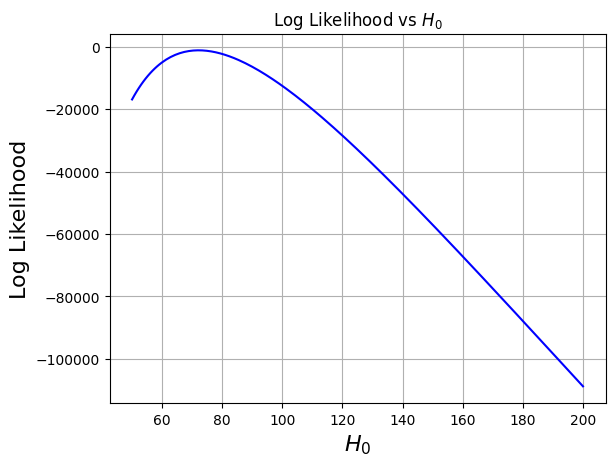

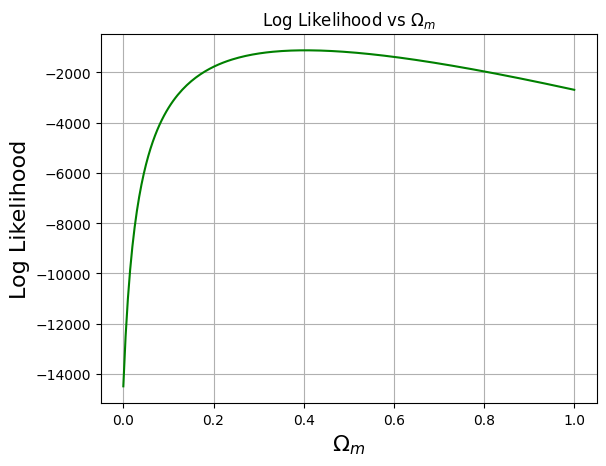

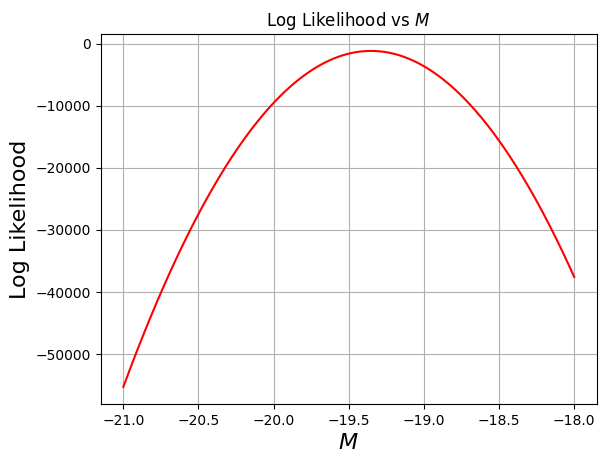

H0 = 70.00, Ωₘ = 0.300, M = -19.30
  chi²_SN  = 952.43
  chi²_BAO = 1044.32
  chi²_CC  = 48.49
  chi²_QSO  = 448.56
  Total chi² = 2493.79
----------------------------------------
mu_th[:5] = [28.59246374 28.59246374 30.20411319 30.20411319 30.54198998]
chi2_SN = 952.4289876310447


In [ ]:
def log_likelihood(theta):
    H0, omega_m, M = theta

    # Supernova chi²
    mu_th = distance_modulus(z_sn, H0, omega_m)
    chi2_SN = chi_square_super(mu_obs, mu_th, mu_err, M)

    # BAO
    chi2_BAO = chi_squared((omega_m, H0, rd), bao_data)

    # CC
    chi2_CC = chi2_cc(H0, omega_m)

    # QSO
    chi2_QSO = chi2_qso(H0, omega_m)
    chi2_total = chi2_SN + chi2_BAO + chi2_CC + chi2_QSO
    return -0.5 * chi2_total
H0_vals = np.linspace(50, 200, 200)
pp_H0 = [log_likelihood([h0, 0.3, -19.3]) for h0 in H0_vals]

plt.figure()
plt.plot(H0_vals, pp_H0, color='blue')
plt.xlabel(r'$H_0$', fontsize=16)
plt.ylabel('Log Likelihood', fontsize=16)
plt.title(r'Log Likelihood vs $H_0$')
plt.grid(True)
plt.show()

omega_m_vals = np.linspace(0, 1, 200)
pp_omega_m = [log_likelihood([70, om, -19.3]) for om in omega_m_vals]

plt.figure()
plt.plot(omega_m_vals, pp_omega_m, color='green')
plt.xlabel(r'$\Omega_m$', fontsize=16)
plt.ylabel('Log Likelihood', fontsize=16)
plt.title(r'Log Likelihood vs $\Omega_m$')
plt.grid(True)
plt.show()

M_vals = np.linspace(-21, -18, 200)
pp_M = [log_likelihood([70, 0.3, m]) for m in M_vals]

plt.figure()
plt.plot(M_vals, pp_M, color='red')
plt.xlabel(r'$M$', fontsize=16)
plt.ylabel('Log Likelihood', fontsize=16)
plt.title(r'Log Likelihood vs $M$')
plt.grid(True)
plt.show()

def log_likelihood(theta, verbose=False):  # add a flag
    H0, omega_m, M = theta

    # --- Supernova chi2 ---
    mu_th = distance_modulus(z_sn, H0, omega_m)
    chi2_SN = chi_square_super(mu_obs, mu_th, mu_err, M)

    # --- BAO chi2 ---
    chi2_BAO = chi_squared((omega_m, H0, rd), bao_data)

    # --- CC chi2 ---
    chi2_CC = chi2_cc(H0, omega_m)
    # QSO
    chi2_QSO = chi2_qso(H0, omega_m)
    chi2_total = chi2_SN + chi2_BAO + chi2_CC + chi2_QSO

    # Print breakdown if requested
    if verbose:
        print(f"H0 = {H0:.2f}, Ωₘ = {omega_m:.3f}, M = {M:.2f}")
        print(f"  chi²_SN  = {chi2_SN:.2f}")
        print(f"  chi²_BAO = {chi2_BAO:.2f}")
        print(f"  chi²_CC  = {chi2_CC:.2f}")
        print(f"  chi²_QSO  = {chi2_QSO:.2f}")
        print(f"  Total chi² = {chi2_total:.2f}")
        print("-" * 40)

    return -0.5 * chi2_total
log_likelihood([70, 0.3, -19.3], verbose=True)
mu_th = distance_modulus(z_sn, 70.0, 0.3)
print("mu_th[:5] =", mu_th[:5])
chi2_SN = chi_square_super(mu_obs, mu_th, mu_err, -19.3)
print("chi2_SN =", chi2_SN)


In [ ]:
import numpy as np
import scipy.optimize as optimize

def log_prior(theta): #uniform prior
  H0, omega_m, M = theta
  if 50< H0 < 200 and 0< omega_m < 1 and -21< M < -18:
    return 0.0
  return -np.inf

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

In [ ]:
import scipy.optimize as optimize

def chi2(theta):
    H0, omega_m, M = theta
    chi= -2 * log_posterior(theta)
    return chi

initial_guess = [69, 0.3, -19.3]
result = optimize.minimize(chi2, initial_guess,method='nelder-mead',
                     options={'maxiter':10000,'xtol': 1e-8, 'disp': True})
if result.success:
    fitted_params = result.x
    print(fitted_params)
else:
    raise ValueError(result.message)

/tmp/ipython-input-8-1269555749.py:9: OptimizeWarning: Unknown solver options: xtol
  result = optimize.minimize(chi2, initial_guess,method='nelder-mead',


Optimization terminated successfully.
         Current function value: 2218.702053
         Iterations: 77
         Function evaluations: 141
[ 71.33120612   0.36815903 -19.28903725]


In [ ]:
!pip install emcee
import emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.0 MB/s eta 0:00:00


In [ ]:
!python -m pip install -U pip
!pip install -U setuptools setuptools_scm pep517
!pip install -U emcee
!pip install -U corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [setuptools_scm]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
import emcee
import corner
import time
import numpy as np
import scipy.optimize as op
import matplotlib.pyplot as plt
from numpy import *

#defining no. of dimensions, walker and steps per walker
ndimension=3 # Changed from 2 to 3
no_of_walkers=6
no_of_steps_per_walker= 5000

#choosing initial value for each pf walker, i.e. close to the number given by optimization method
initial_pos_of_walker = [result["x"] + 1e-4*np.random.randn(ndimension) for i in range(no_of_walkers)]
print(initial_pos_of_walker)

[array([ 71.33102888,   0.36834412, -19.28916812]), array([ 71.33133397,   0.36810008, -19.28921269]), array([ 71.33127948,   0.36798721, -19.28900538]), array([ 71.33129719,   0.36811626, -19.28893763]), array([ 71.33112121,   0.36814871, -19.28896224]), array([ 71.33122593,   0.36817518, -19.28900004])]


In [ ]:
sampler = emcee.EnsembleSampler(no_of_walkers, ndimension, log_posterior, a=2)
print(sampler)
sampler.run_mcmc(initial_pos_of_walker, no_of_steps_per_walker, rstate0=np.random.get_state(),progress=True);

100%|██████████| 5000/5000 [35:12<00:00,  2.37it/s]


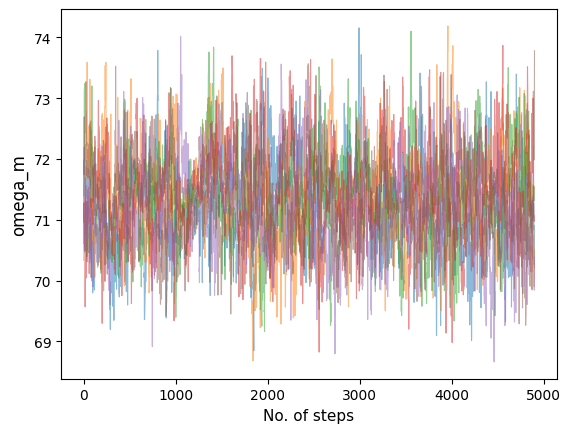

In [ ]:
burn_in_steps=100
for i in range(0,no_of_walkers):
  omega_m=sampler.chain[i,burn_in_steps:,0]  #sampler.chain[No of walker,burn_in_steps:,column in the walker array]
  plt.plot(omega_m, alpha=0.5, lw=0.8)
plt.xlabel("No. of steps", fontsize=11)
plt.ylabel("omega_m", fontsize=12)
plt.show()

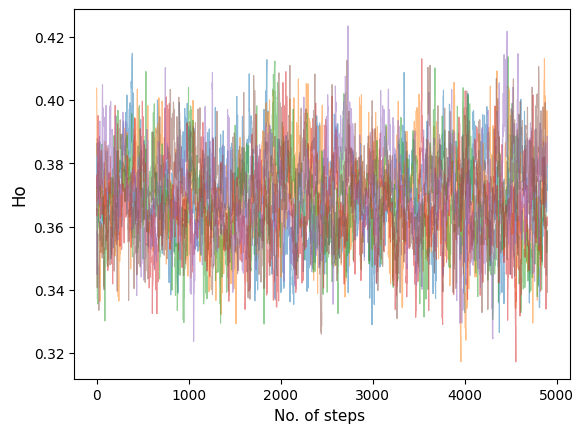

In [ ]:
for i in range(0,no_of_walkers):
  H0=sampler.chain[i,burn_in_steps:,1]

  plt.plot(H0, alpha=0.5, lw=0.8)
plt.xlabel("No. of steps ", fontsize=11)
plt.ylabel("Ho", fontsize=12)
plt.show()

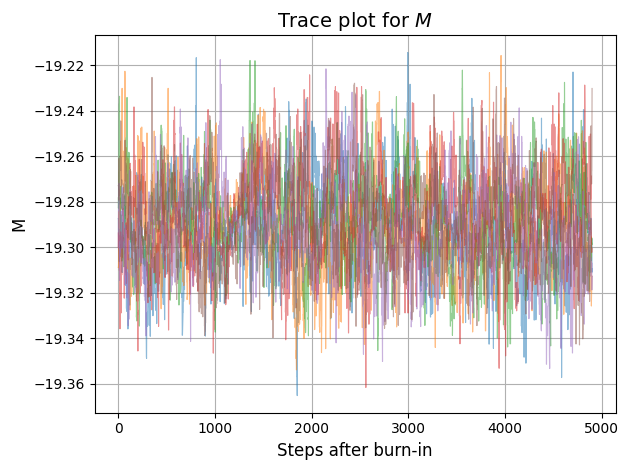

In [ ]:

for i in range(no_of_walkers):
    M = sampler.chain[i, burn_in_steps:, 2]  # use column 2 for M
    plt.plot(M, alpha=0.5, lw=0.8)
plt.xlabel("Steps after burn-in", fontsize=12)
plt.ylabel("M", fontsize=12)
plt.title("Trace plot for $M$", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


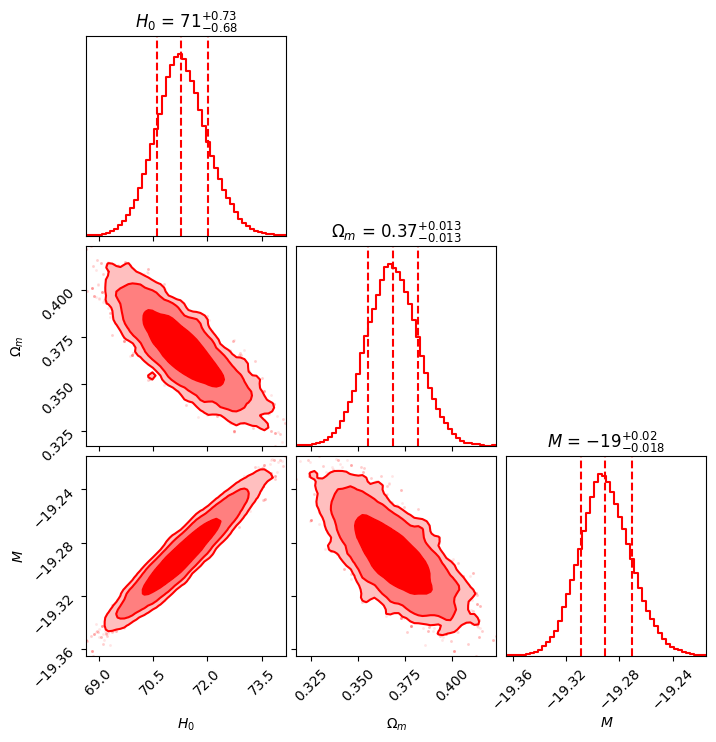

In [ ]:
import corner
import matplotlib.pyplot as plt

# Reshape the samples from the MCMC sampler
samples = sampler.chain[:, burn_in_steps:, :].reshape((-1, ndimension))

# Create corner plot
fig = corner.corner(
    samples,
    bins=50,
    labels=["$H_0$", r"$\Omega_m$", r"$M$"],
    quantiles=[0.16, 0.5, 0.84],
    color="red",
    plot_contours=True,
    fill_contours=True,
    levels=(0.68, 0.95, 0.99),
    plot_datapoints=True,
    smooth=True,
    smooth1d=True,
    title_fmt=".2g",
    show_titles=True,
    figsize=(4, 4)
)
#corner.corner(samples, figsize=(2, 2))
# Save and show plot
plt.savefig("emcmc_result.png", dpi=200)
plt.show()
